# Classificazione Patologie ECG con CNN Embedded
### Approccio gerarchico a due stadi

Notebook di lavoro per l'addestramento di CNN 1D su segnale ECG grezzo, con deploy finale su microcontrollore STM32F411 (Cortex-M4).

**Dataset**: MIT-BIH Arrhythmia Database (PhysioNet)
**Approccio**: raw signal, nessuna feature engineering manuale
**Pipeline**: Stadio 1 (Normale vs Anomalo) -> Stadio 2 (sotto-classificazione S/V/F/Q)

## 0. Avvio rapido (se il dataset e' gia' stato salvato su Drive)

Se hai gia' eseguito il salvataggio (Sezione 6bis) in una sessione precedente, esegui solo questa cella per ricaricare train/val/test gia' pronti, saltando direttamente alla Sezione 7. Altrimenti, procedi dalla Sezione 1 come al solito.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'

X_train = np.load(f'{SALVA_DIR}/X_train.npy')
y_train = np.load(f'{SALVA_DIR}/y_train.npy')
X_val = np.load(f'{SALVA_DIR}/X_val.npy')
y_val = np.load(f'{SALVA_DIR}/y_val.npy')
X_test = np.load(f'{SALVA_DIR}/X_test.npy')
y_test = np.load(f'{SALVA_DIR}/y_test.npy')

print('Dataset ricaricato da Drive:')
print(f'Training:   {X_train.shape}')
print(f'Validation: {X_val.shape}')
print(f'Test:       {X_test.shape}')

Mounted at /content/drive
Dataset ricaricato da Drive:
Training:   (75395, 300)
Validation: (14911, 300)
Test:       (19140, 300)


## 1. Setup ambiente

Installazione della libreria `wfdb` per leggere i segnali PhysioNet direttamente da Colab, senza download manuale.

In [ ]:
!pip install wfdb -q

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

## 2. Esplorazione preliminare (record 100)

Analisi di un singolo record per capire struttura fisica del segnale, formato delle annotazioni, aspetto visivo del tracciato.

In [ ]:
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

print('Frequenza di campionamento:', record.fs, 'Hz')
print('Numero di canali:', record.n_sig)
print('Nomi dei canali:', record.sig_name)
print('Durata (campioni):', record.sig_len)
print('Durata (secondi):', record.sig_len / record.fs)
print('Forma dei dati:', record.p_signal.shape)

In [ ]:
wfdb.plot_wfdb(record=record, annotation=annotation,
               title='MIT-BIH Record 100 - vista completa', time_units='seconds')

## 3. Download completo del dataset (48 record)

Scarichiamo segnale e annotazioni di tutti i 48 record, applicando la mappatura verso le 5 classi cliniche standard AAMI (N, S, V, F, Q). I simboli tecnici non associati a un battito vengono scartati.

In [ ]:
record_names = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

dataset = {}

for rec_name in record_names:
    record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
    ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')

    campioni_validi = []
    classi_valide = []
    for campione, simbolo in zip(ann.sample, ann.symbol):
        if simbolo in aami_map:
            campioni_validi.append(campione)
            classi_valide.append(aami_map[simbolo])

    dataset[rec_name] = {
        'signal': record.p_signal,
        'fs': record.fs,
        'beat_samples': np.array(campioni_validi),
        'beat_labels': np.array(classi_valide)
    }

    print(f'Record {rec_name}: {len(campioni_validi)} battiti validi')

print(f'\nTutti i {len(record_names)} record scaricati e salvati in dataset')

In [ ]:
conteggio_aami = Counter()
for rec_name in dataset:
    conteggio_aami.update(dataset[rec_name]['beat_labels'])

totale_battiti = sum(conteggio_aami.values())
print('--- Distribuzione classi AAMI su tutto il dataset ---')
for classe, conteggio in sorted(conteggio_aami.items(), key=lambda x: -x[1]):
    perc = 100 * conteggio / totale_battiti
    print(f"Classe '{classe}': {conteggio} ({perc:.1f}%)")
print(f'\nTotale battiti utilizzabili: {totale_battiti}')

## 4. Segmentazione dei battiti

Finestra fissa attorno al picco R: 100 campioni prima, 200 dopo (300 totali, ~0.83s a 360Hz). Solo canale 0 (MLII).

In [ ]:
FINESTRA_PRIMA = 100
FINESTRA_DOPO = 200
CANALE = 0

## 5. Preprocessing del segnale

Filtro passa-banda (0.5-40 Hz) sull'intero segnale di ogni record, seguito da segmentazione e normalizzazione z-score per finestra.

In [ ]:
from scipy.signal import butter, filtfilt

def filtro_passabanda(segnale, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, segnale)

for rec_name in dataset:
    segnale_grezzo = dataset[rec_name]['signal'][:, CANALE]
    dataset[rec_name]['signal_filtered'] = filtro_passabanda(segnale_grezzo, dataset[rec_name]['fs'])

print('Filtro passa-banda applicato a tutti i record.')

In [ ]:
X = []
y = []
record_id = []
beat_position = []

for rec_name in dataset:
    segnale = dataset[rec_name]['signal_filtered']
    campioni_battiti = dataset[rec_name]['beat_samples']
    classi_battiti = dataset[rec_name]['beat_labels']

    for campione, classe in zip(campioni_battiti, classi_battiti):
        inizio = campione - FINESTRA_PRIMA
        fine = campione + FINESTRA_DOPO

        if inizio < 0 or fine > len(segnale):
            continue

        segmento = segnale[inizio:fine]
        media = np.mean(segmento)
        std = np.std(segmento)
        segmento_normalizzato = (segmento - media) / (std + 1e-8)

        X.append(segmento_normalizzato)
        y.append(classe)
        record_id.append(rec_name)
        beat_position.append(campione)

X = np.array(X)
y = np.array(y)
record_id = np.array(record_id)
beat_position = np.array(beat_position)

print(f'Segmenti totali estratti: {len(X)}')
print(f'Forma di X: {X.shape}')
print(f'Battiti scartati per bordo: {totale_battiti - len(X)}')

## 6. Split Train / Validation / Test per paziente

Split per record (non per singolo battito) per evitare data leakage. Proporzioni: 70% train / 15% val / 15% test.

In [ ]:
from sklearn.model_selection import train_test_split

record_unici = np.array(record_names)

record_train, record_valtest = train_test_split(record_unici, test_size=0.30, random_state=42)
record_val, record_test = train_test_split(record_valtest, test_size=0.50, random_state=42)

print(f'Record in training:   {len(record_train)}')
print(f'Record in validation: {len(record_val)}')
print(f'Record in test:       {len(record_test)}')

In [ ]:
mask_train = np.isin(record_id, record_train)
mask_val = np.isin(record_id, record_val)
mask_test = np.isin(record_id, record_test)

X_train, y_train = X[mask_train], y[mask_train]
X_val, y_val = X[mask_val], y[mask_val]
X_test, y_test = X[mask_test], y[mask_test]

print(f'Training:   {X_train.shape[0]} segmenti')
print(f'Validation: {X_val.shape[0]} segmenti')
print(f'Test:       {X_test.shape[0]} segmenti')

## 6bis. Salvataggio del dataset processato su Google Drive

Evita di rieseguire download/preprocessing ad ogni disconnessione. Esegui una volta, poi usa la Sezione 0 nelle sessioni successive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'
os.makedirs(SALVA_DIR, exist_ok=True)

np.save(f'{SALVA_DIR}/X_train.npy', X_train)
np.save(f'{SALVA_DIR}/y_train.npy', y_train)
np.save(f'{SALVA_DIR}/X_val.npy', X_val)
np.save(f'{SALVA_DIR}/y_val.npy', y_val)
np.save(f'{SALVA_DIR}/X_test.npy', X_test)
np.save(f'{SALVA_DIR}/y_test.npy', y_test)

print('Dataset processato salvato su Google Drive in:', SALVA_DIR)

## 7. Codifica delle etichette e reshape per Keras

In [3]:
classe_to_int = {classe: i for i, classe in enumerate(sorted(np.unique(np.concatenate([y_train, y_val, y_test]))))}
int_to_classe = {i: classe for classe, i in classe_to_int.items()}
print('Mappa classi -> interi:', classe_to_int)

y_train_int = np.array([classe_to_int[c] for c in y_train])
y_val_int = np.array([classe_to_int[c] for c in y_val])
y_test_int = np.array([classe_to_int[c] for c in y_test])

num_classi = len(classe_to_int)

X_train_r = X_train.reshape(-1, X_train.shape[1], 1)
X_val_r = X_val.reshape(-1, X_val.shape[1], 1)
X_test_r = X_test.reshape(-1, X_test.shape[1], 1)

print(f'Forma X_train per Keras: {X_train_r.shape}')

Mappa classi -> interi: {np.str_('F'): 0, np.str_('N'): 1, np.str_('Q'): 2, np.str_('S'): 3, np.str_('V'): 4}
Forma X_train per Keras: (75395, 300, 1)


## 8. Architettura CNN 1D (funzione riutilizzata per entrambi gli stadi)

Rete compatta a 3 blocchi convoluzionali con GlobalAveragePooling1D, pensata per il deploy su STM32F411. La stessa funzione costruisce sia il classificatore binario (Stadio 1) sia quello multiclasse (Stadio 2).

In [4]:
from tensorflow.keras import layers, models

def costruisci_modello(input_shape, num_output, attivazione_finale):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(16, kernel_size=9, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(32, kernel_size=7, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(64, kernel_size=5, padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),

        layers.GlobalAveragePooling1D(),
        layers.Dense(num_output, activation=attivazione_finale)
    ])
    return model

## 9. Stadio 1 -- Classificatore binario: Normale vs Anomalo

Rietichettiamo il problema: N resta N, tutto il resto (S+V+F+Q) diventa un'unica classe 'Anomalo'. Sbilanciamento molto piu' contenuto rispetto al problema a 5 classi originale.

In [5]:
indice_N = classe_to_int['N']

y_train_bin = (y_train_int != indice_N).astype(int)
y_val_bin = (y_val_int != indice_N).astype(int)
y_test_bin = (y_test_int != indice_N).astype(int)

n_normali = (y_train_bin == 0).sum()
n_anomali = (y_train_bin == 1).sum()
print(f'Normale: {n_normali} ({100*n_normali/len(y_train_bin):.1f}%)')
print(f'Anomalo: {n_anomali} ({100*n_anomali/len(y_train_bin):.1f}%)')
print(f'Rapporto sbilanciamento: {n_normali/n_anomali:.1f}:1')

Normale: 61382 (81.4%)
Anomalo: 14013 (18.6%)
Rapporto sbilanciamento: 4.4:1


In [6]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

pesi_s1 = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y_train_bin)
class_weights_s1 = {0: pesi_s1[0], 1: pesi_s1[1]}
print('Class weights Stadio 1:', class_weights_s1)

model_stadio1 = costruisci_modello(input_shape=(X_train_r.shape[1], 1), num_output=1, attivazione_finale='sigmoid')

model_stadio1.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_s1 = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr_s1 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_s1 = model_stadio1.fit(
    X_train_r, y_train_bin,
    validation_data=(X_val_r, y_val_bin),
    epochs=60,
    batch_size=64,
    class_weight=class_weights_s1,
    callbacks=[early_stop_s1, reduce_lr_s1],
    verbose=1
)

Class weights Stadio 1: {0: np.float64(0.6141458408002346), 1: np.float64(2.690180546635267)}
Epoch 1/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 64s 52ms/step - accuracy: 0.8984 - loss: 0.2966 - val_accuracy: 0.5876 - val_loss: 0.7711 - learning_rate: 3.0000e-04
Epoch 2/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.9483 - loss: 0.1897 - val_accuracy: 0.9458 - val_loss: 0.1967 - learning_rate: 3.0000e-04
Epoch 3/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 79s 47ms/step - accuracy: 0.9563 - loss: 0.1578 - val_accuracy: 0.9445 - val_loss: 0.1903 - learning_rate: 3.0000e-04
Epoch 4/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - accuracy: 0.9611 - loss: 0.1412 - val_accuracy: 0.9343 - val_loss: 0.2052 - learning_rate: 3.0000e-04
Epoch 5/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 57s 48ms/step - accuracy: 0.9629 - loss: 0.1347 - val_accuracy: 0.8696 - val_loss: 0.3335 - learning_rate: 3.0000e-04
Epoch 6/60
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - accuracy: 0.9656 - loss: 0.1269 - val_accuracy: 

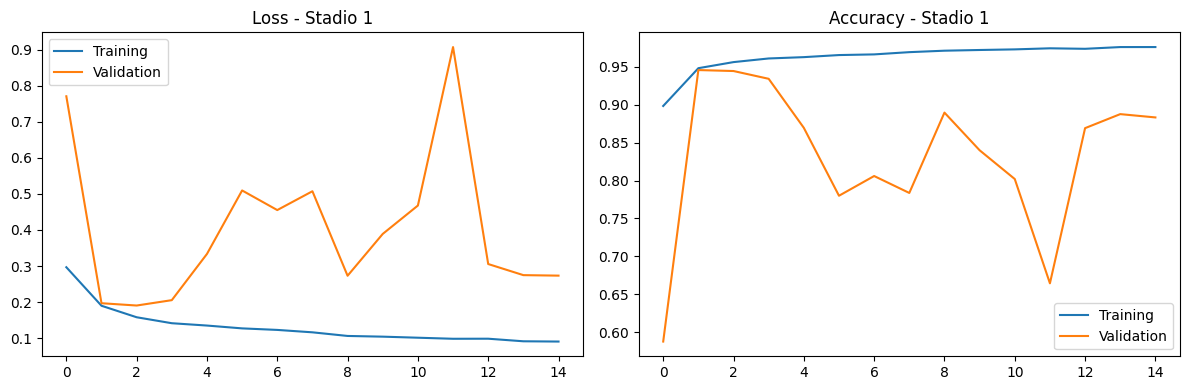

466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


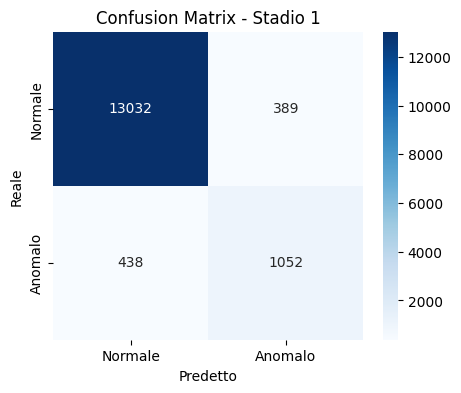

              precision    recall  f1-score   support

     Normale       0.97      0.97      0.97     13421
     Anomalo       0.73      0.71      0.72      1490

    accuracy                           0.94     14911
   macro avg       0.85      0.84      0.84     14911
weighted avg       0.94      0.94      0.94     14911



In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_s1.history['loss'], label='Training')
axes[0].plot(history_s1.history['val_loss'], label='Validation')
axes[0].set_title('Loss - Stadio 1')
axes[0].legend()
axes[1].plot(history_s1.history['accuracy'], label='Training')
axes[1].plot(history_s1.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy - Stadio 1')
axes[1].legend()
plt.tight_layout()
plt.show()

y_val_pred_s1 = (model_stadio1.predict(X_val_r) > 0.5).astype(int).flatten()

cm_s1 = confusion_matrix(y_val_bin, y_val_pred_s1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_s1, annot=True, fmt='d', xticklabels=['Normale','Anomalo'], yticklabels=['Normale','Anomalo'], cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.title('Confusion Matrix - Stadio 1')
plt.show()

print(classification_report(y_val_bin, y_val_pred_s1, target_names=['Normale','Anomalo']))

## 10. Stadio 2 -- Sotto-classificazione: S / V / F / Q

Alleniamo un secondo modello solo sui segmenti realmente anomali (esclusi gli N), su un problema a 4 classi dove F non compete piu' contro l'enorme maggioranza N.

In [8]:
mask_anom_train = y_train_int != indice_N
mask_anom_val = y_val_int != indice_N

X_train_anom = X_train_r[mask_anom_train]
X_val_anom = X_val_r[mask_anom_val]

classi_anomale = sorted([c for c in classe_to_int if c != 'N'])
classe_to_int_s2 = {c: i for i, c in enumerate(classi_anomale)}
int_to_classe_s2 = {i: c for c, i in classe_to_int_s2.items()}
print('Mappa Stadio 2:', classe_to_int_s2)

y_train_s2 = np.array([classe_to_int_s2[int_to_classe[i]] for i in y_train_int[mask_anom_train]])
y_val_s2 = np.array([classe_to_int_s2[int_to_classe[i]] for i in y_val_int[mask_anom_val]])

print(f'Esempi anomali in training: {len(y_train_s2)}')
print(f'Esempi anomali in validation: {len(y_val_s2)}')
for c, i in classe_to_int_s2.items():
    n = (y_train_s2 == i).sum()
    print(f'  {c}: {n} ({100*n/len(y_train_s2):.1f}%)')

Mappa Stadio 2: {np.str_('F'): 0, np.str_('Q'): 1, np.str_('S'): 2, np.str_('V'): 3}
Esempi anomali in training: 14013
Esempi anomali in validation: 1490
  F: 422 (3.0%)
  Q: 5973 (42.6%)
  S: 2336 (16.7%)
  V: 5282 (37.7%)


In [9]:
pesi_s2_arr = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_s2), y=y_train_s2)
class_weights_s2 = dict(zip(np.unique(y_train_s2), pesi_s2_arr))
print('Class weights Stadio 2:', class_weights_s2)

model_stadio2 = costruisci_modello(input_shape=(X_train_r.shape[1], 1), num_output=len(classi_anomale), attivazione_finale='softmax')

model_stadio2.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_s2 = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr_s2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_s2 = model_stadio2.fit(
    X_train_anom, y_train_s2,
    validation_data=(X_val_anom, y_val_s2),
    epochs=60,
    batch_size=64,
    class_weight=class_weights_s2,
    callbacks=[early_stop_s2, reduce_lr_s2],
    verbose=1
)

Class weights Stadio 2: {np.int64(0): np.float64(8.30154028436019), np.int64(1): np.float64(0.5865143144148669), np.int64(2): np.float64(1.4996789383561644), np.int64(3): np.float64(0.6632430897387354)}
Epoch 1/60
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.7126 - loss: 0.7889 - val_accuracy: 0.6423 - val_loss: 1.0578 - learning_rate: 3.0000e-04
Epoch 2/60
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.9182 - loss: 0.3968 - val_accuracy: 0.6852 - val_loss: 0.8871 - learning_rate: 3.0000e-04
Epoch 3/60
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9341 - loss: 0.3001 - val_accuracy: 0.6805 - val_loss: 0.8113 - learning_rate: 3.0000e-04
Epoch 4/60
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 51ms/step - accuracy: 0.9413 - loss: 0.2532 - val_accuracy: 0.7027 - val_loss: 0.8559 - learning_rate: 3.0000e-04
Epoch 5/60
219/219 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.9478 - loss: 0.2187 - val_accuracy: 0.6805 - val_loss: 0.7685 - learning_rate: 3.0000e-04
Epoch 6

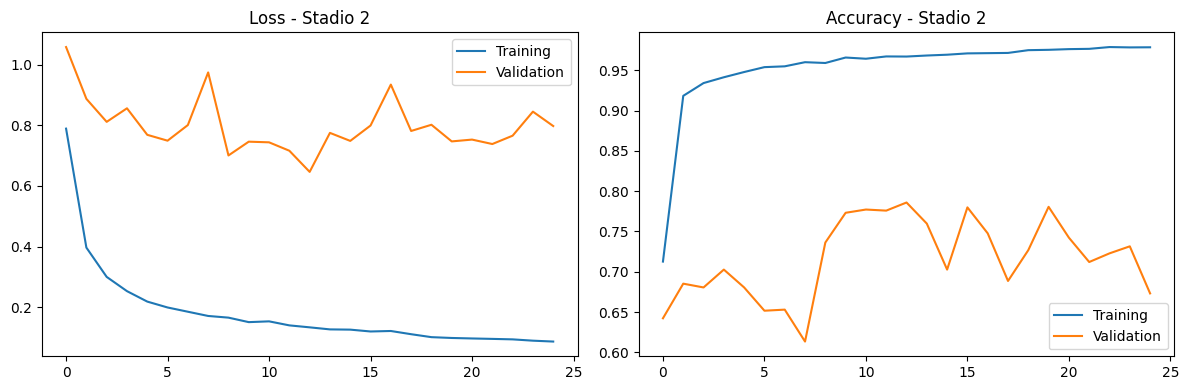

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


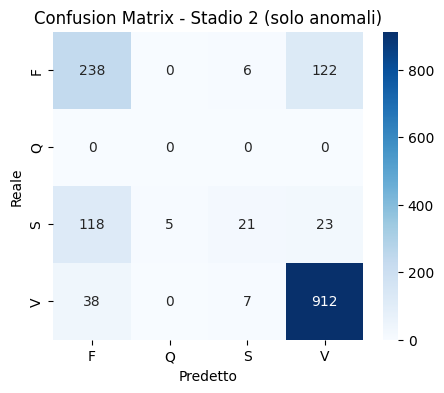

              precision    recall  f1-score   support

           F       0.60      0.65      0.63       366
           Q       0.00      0.00      0.00         0
           S       0.62      0.13      0.21       167
           V       0.86      0.95      0.91       957

    accuracy                           0.79      1490
   macro avg       0.52      0.43      0.44      1490
weighted avg       0.77      0.79      0.76      1490



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_s2.history['loss'], label='Training')
axes[0].plot(history_s2.history['val_loss'], label='Validation')
axes[0].set_title('Loss - Stadio 2')
axes[0].legend()
axes[1].plot(history_s2.history['accuracy'], label='Training')
axes[1].plot(history_s2.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy - Stadio 2')
axes[1].legend()
plt.tight_layout()
plt.show()

y_val_pred_s2 = np.argmax(model_stadio2.predict(X_val_anom), axis=1)
nomi_s2 = [int_to_classe_s2[i] for i in range(len(classi_anomale))]

cm_s2 = confusion_matrix(y_val_s2, y_val_pred_s2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_s2, annot=True, fmt='d', xticklabels=nomi_s2, yticklabels=nomi_s2, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.title('Confusion Matrix - Stadio 2 (solo anomali)')
plt.show()

print(classification_report(y_val_s2, y_val_pred_s2, target_names=nomi_s2, zero_division=0))

## 11. Pipeline combinata -- Valutazione end-to-end

Uniamo i due stadi in cascata: ogni segmento passa prima per lo Stadio 1; se 'Anomalo', passa allo Stadio 2 per la sotto-classificazione. Valutiamo il risultato finale confrontato con le etichette originali a 5 classi.

466/466 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


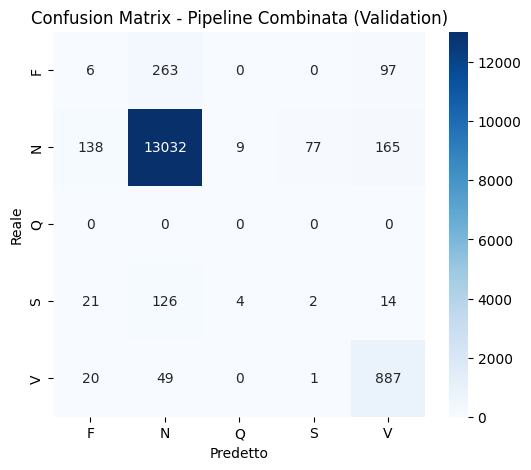

              precision    recall  f1-score   support

           F       0.03      0.02      0.02       366
           N       0.97      0.97      0.97     13421
           Q       0.00      0.00      0.00         0
           S       0.03      0.01      0.02       167
           V       0.76      0.93      0.84       957

    accuracy                           0.93     14911
   macro avg       0.36      0.39      0.37     14911
weighted avg       0.92      0.93      0.93     14911



In [11]:
pred_s1_val = (model_stadio1.predict(X_val_r) > 0.5).astype(int).flatten()
pred_finale = np.full(len(y_val_int), indice_N)

idx_anomali_predetti = np.where(pred_s1_val == 1)[0]
if len(idx_anomali_predetti) > 0:
    pred_s2_su_predetti = np.argmax(model_stadio2.predict(X_val_r[idx_anomali_predetti]), axis=1)
    for pos, idx in enumerate(idx_anomali_predetti):
        classe_lettera = int_to_classe_s2[pred_s2_su_predetti[pos]]
        pred_finale[idx] = classe_to_int[classe_lettera]

nomi_classi_finali = [int_to_classe[i] for i in range(num_classi)]

cm_finale = confusion_matrix(y_val_int, pred_finale)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_finale, annot=True, fmt='d', xticklabels=nomi_classi_finali, yticklabels=nomi_classi_finali, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.title('Confusion Matrix - Pipeline Combinata (Validation)')
plt.show()

print(classification_report(y_val_int, pred_finale, target_names=nomi_classi_finali, zero_division=0))